# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỷ lệ missing (%) của toàn bộ dataframe:")
print(df.isnull().mean().sort_values(ascending=False) * 100)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
# alive: chính là survived ghi lại bằng chữ -> rò rỉ target trực tiếp
# who, adult_male, class: suy ra được từ sex/age/pclass -> trùng thông tin
# deck: thiếu ~77% -> quá nhiều để dùng đáng tin cậy
# embark_town: trùng embarked; alone: suy ra từ sibsp + parch
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
leaky = [col for col in leaky if col in df.columns]  # chỉ giữ cột thực sự có trong df
df = df.drop(columns=leaky)

print("\nCác cột còn lại:", list(df.columns))

Tỷ lệ missing (%) của toàn bộ dataframe:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` chỉ là `survived` được viết lại dưới dạng chữ (`no`/`yes` thay vì `0`/`1`) — hai cột này chứa **chính xác cùng một thông tin**, chỉ khác định dạng. Nếu để `alive` trong tập đặc trưng (`X`) trong khi `survived` là nhãn (`y`), mô hình sẽ không cần học bất kỳ quy luật nào từ `pclass`, `sex`, `age`,... — nó chỉ cần "đọc" giá trị `alive` là suy ra ngay `survived` với độ chính xác gần như tuyệt đối.

Đây chính là **data leakage**: thông tin đáng lẽ mô hình không được nhìn thấy (vì nó chính là cái cần dự đoán) lại bị "rò" vào tập đặc trưng. Kết quả là accuracy trên tập train/test đều đẹp (~100%) nhưng đó là ảo giác — mô hình không học được quy luật thực sự nào về sinh tồn, và khi gặp dữ liệu hành khách mới hoàn toàn (không có sẵn cột `alive`), mô hình sẽ **không thể dự đoán được gì cả**. Do đó phải loại `alive` (và các cột suy ra trực tiếp/gián tiếp từ nhãn) trước khi đưa dữ liệu vào mô hình.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print("Số dòng:", df.shape[0])
print("\n Số cột:", df.shape[1])
print("\n Thông tin DataFrame:", df.info())
print("\n Thống kê mô tả:", df.describe(include=["object", "category", "number"]))


Số dòng: 891

 Số cột: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB

 Thông tin DataFrame: None

 Thống kê mô tả:           survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN        

**Trả lời 2 (biến số vs biến phân loại):**

- Cột là biến số là cột có kiểu dữ liệu dtype là int64 và float64 : survied, pclass, sibsp, parch, fare. 

- Cột là iến phân loại là cột có kiểu dữ liệu dtype là category : class. 

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100
missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})
# chỉ hiển thị các cột thực sự có missing, sắp theo % giảm dần
missing_table = missing_table[missing_table["missing_count"] > 0].sort_values("missing_percent", ascending=False)
print(missing_table)

          missing_count  missing_percent
age                 177            19.87
embarked              2             0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~19.9% | Điền bằng **median** | Tỷ lệ thiếu vừa phải (không quá lớn để phải bỏ cột), là biến số nên không thể điền mode. `age` có outlier (người già/trẻ sơ sinh) nên **median bền vững hơn mean** — mean sẽ bị outlier kéo lệch, còn median phản ánh đúng độ tuổi "điển hình" hơn. |
| `embarked` | ~0.2% (chỉ 2 dòng) | Điền bằng **mode (giá trị xuất hiện nhiều nhất)** | Đây là biến phân loại nên dùng mean/median không có ý nghĩa. Tỷ lệ thiếu cực nhỏ (2/891 dòng) nên dù chọn cách điền nào cũng gần như không ảnh hưởng đến phân phối chung — điền mode (`S` — Southampton, cảng phổ biến nhất) là lựa chọn đơn giản và an toàn nhất. |

*(Các cột còn lại như `deck`, `embark_town` đã bị loại ngay từ Task 1 nên không xuất hiện trong bảng missing này.)*

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z_score = (s - s.mean()) / s.std()
    return (np.abs(z_score) > nguong).sum()

for col in ["age", "fare"]:
    n_iqr = dem_outlier_iqr(df[col])
    n_z = dem_outlier_zscore(df[col])
    print(f"Cột {col}: outlier theo IQR = {n_iqr}, outlier theo Z-score = {n_z}")

Cột age: outlier theo IQR = 11, outlier theo Z-score = 2
Cột fare: outlier theo IQR = 116, outlier theo Z-score = 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Với `fare`, IQR phát hiện tới **116 outlier** trong khi Z-score chỉ phát hiện **20** — chênh lệch lớn vì `fare` phân phối **lệch phải rất mạnh** (đa số vé rẻ, một số ít vé rất đắt), khiến `mean`/`std` (dùng trong Z-score) bị kéo lệch theo các giá trị lớn, còn IQR (dựa trên phần trăm vị) nhạy hơn với kiểu lệch này.

**Quyết định: giữ lại** các outlier của `fare`, không xóa hay ép về giới hạn. Lý do:
- Đây **không phải lỗi nhập liệu** — vé hạng nhất (First class) trên Titanic thực sự có giá cao gấp nhiều lần vé hạng ba, đây là hiện tượng thật phản ánh cấu trúc giá vé theo hạng ghế.
- `fare` tương quan khá rõ với `survived` (xem Task 5), nên các giá trị cao — dù là "outlier" về mặt thống kê — lại mang **thông tin dự đoán hữu ích**, xóa đi sẽ làm mất tín hiệu quan trọng.
- Thay vì xóa, cách xử lý phù hợp hơn là dùng **`RobustScaler`** khi scale (dựa trên median/IQR thay vì mean/std), giúp mô hình không bị các giá trị cực đại này "lấn át" mà vẫn giữ nguyên thông tin.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

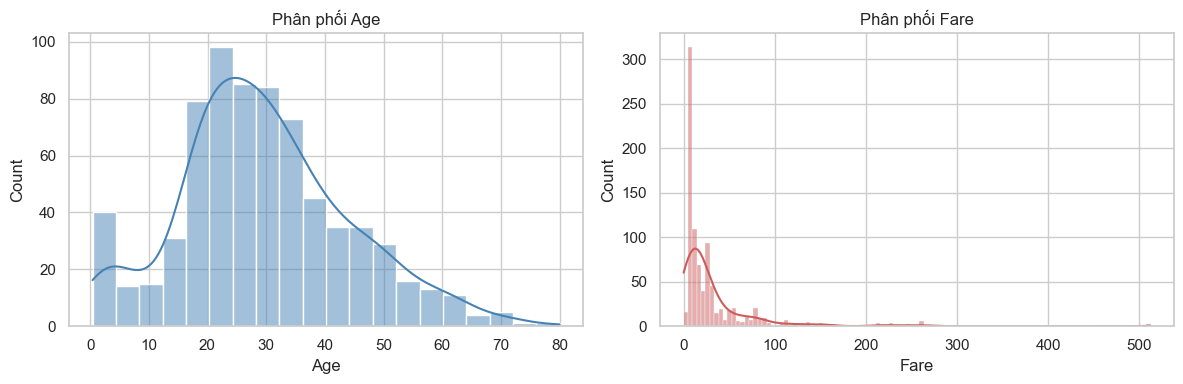

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["age"].dropna(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối Age")
axes[0].set_xlabel("Age")

sns.histplot(df["fare"], kde=True, ax=axes[1], color="indianred")
axes[1].set_title("Phân phối Fare")
axes[1].set_xlabel("Fare")

plt.tight_layout()
plt.show()

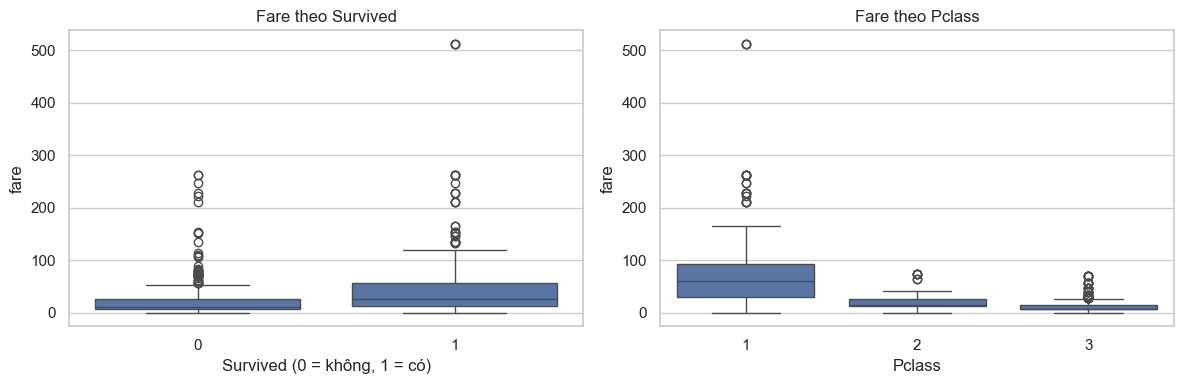

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="survived", y="fare", ax=axes[0])
axes[0].set_title("Fare theo Survived")
axes[0].set_xlabel("Survived (0 = không, 1 = có)")

sns.boxplot(data=df, x="pclass", y="fare", ax=axes[1])
axes[1].set_title("Fare theo Pclass")
axes[1].set_xlabel("Pclass")

plt.tight_layout()
plt.show()

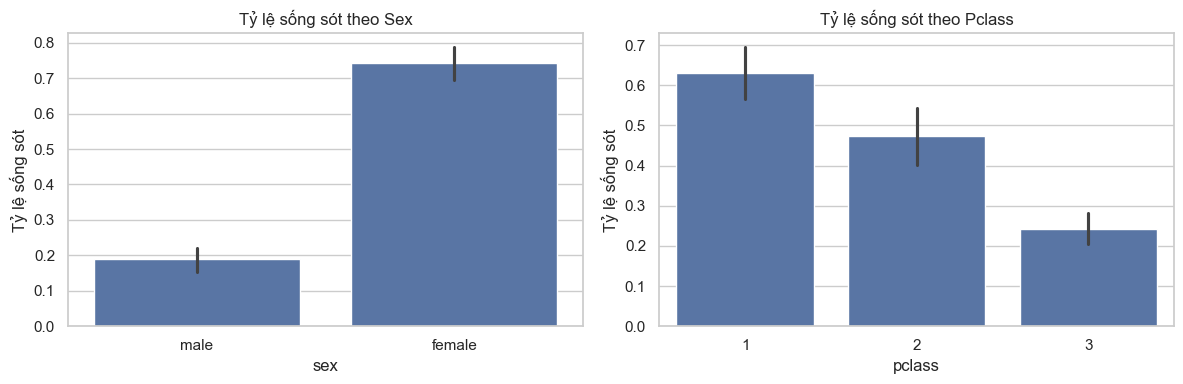

Tỷ lệ sống sót theo sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Tỷ lệ sống sót theo pclass:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo Sex")
axes[0].set_ylabel("Tỷ lệ sống sót")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo Pclass")
axes[1].set_ylabel("Tỷ lệ sống sót")

plt.tight_layout()
plt.show()

# In số liệu cụ thể để dẫn chứng cho phần nhận xét
print("Tỷ lệ sống sót theo sex:")
print(df.groupby("sex")["survived"].mean())
print("\nTỷ lệ sống sót theo pclass:")
print(df.groupby("pclass")["survived"].mean())

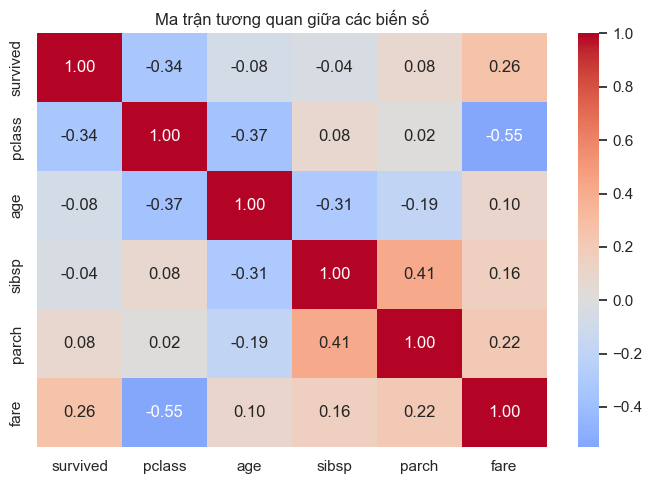

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(7, 5))
corr = df.select_dtypes("number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:** `age` xấp xỉ phân phối chuẩn, hơi lệch phải nhẹ, tập trung quanh 20–40 tuổi, có một đỉnh nhỏ ở trẻ sơ sinh/trẻ em. `fare` **lệch phải rất mạnh** — phần lớn hành khách trả vé rẻ (dưới ~30), nhưng có một nhóm nhỏ trả vé rất cao (trên 200), kéo dài đuôi phân phối về phía phải.
- **Boxplot:** Nhóm `survived=1` có median `fare` cao hơn rõ rệt so với nhóm `survived=0`, và cả hai nhóm đều có nhiều outlier phía trên — khớp với nhận định ở Task 4 rằng vé đắt là hiện tượng thật (hạng nhất) chứ không phải lỗi. Theo `pclass`, `fare` giảm dần rõ rệt từ hạng 1 xuống hạng 3, đúng với logic giá vé theo hạng ghế.
- **Bar survival:** Nữ giới có tỷ lệ sống sót cao hơn nam giới **rất nhiều** (khoảng 74% so với 19%, chênh ~55 điểm %) — phản ánh đúng chính sách "phụ nữ và trẻ em trước" khi sơ tán. Theo `pclass`, hạng 1 có tỷ lệ sống sót cao nhất (~63%), giảm dần xuống hạng 3 (~24%) — cho thấy vị trí khoang và mức độ ưu tiên khi cứu hộ có liên hệ chặt với hạng vé.
- **Heatmap:** Biến tương quan mạnh nhất với `survived` là `pclass` (khoảng −0.34, tương quan âm — hạng vé càng cao số càng nhỏ thì khả năng sống càng cao) và `fare` (khoảng +0.26, tương quan dương). `pclass` và `fare` cũng tương quan âm khá rõ với nhau (vé hạng 1 đắt hơn) — điều này hợp lý vì về bản chất hai biến này cùng phản ánh "vị thế kinh tế – xã hội" của hành khách.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

# Lần 1: tách 15% làm test, giữ 85% còn lại (tmp) để tiếp tục chia train/val
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Lần 2: từ 85% còn lại, tách tiếp để val chiếm ~15% TOÀN BỘ dữ liệu gốc
# => test_size = 0.15 / 0.85 (vì đang chia trên phần 85%, không phải trên toàn bộ)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=42
)

print("Train/Val/Test shape:", X_train.shape, X_val.shape, X_test.shape)
print("\nTỷ lệ sống sót từng tập (kiểm tra stratify hoạt động đúng):")
print(f"  Train: {y_train.mean():.4f}")
print(f"  Val:   {y_val.mean():.4f}")
print(f"  Test:  {y_test.mean():.4f}")
print(f"  Toàn bộ: {y.mean():.4f}")

Train/Val/Test shape: (623, 7) (134, 7) (134, 7)

Tỷ lệ sống sót từng tập (kiểm tra stratify hoạt động đúng):
  Train: 0.3836
  Val:   0.3881
  Test:  0.3806
  Toàn bộ: 0.3838


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # median: bền vững với outlier của fare (xem Task 4)
    ("scaler", RobustScaler()),                       # dựa trên median/IQR -> không bị outlier chi phối
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # biến phân loại -> điền mode
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),   # pclass đã là số có thứ tự 1 < 2 < 3 -> giữ nguyên
])

preprocess.fit(X_train)                     # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print("Shape sau biến đổi - train/val/test:", X_train_t.shape, X_val_t.shape, X_test_t.shape)
print("\nTên cột sau biến đổi:")
print(list(preprocess.get_feature_names_out()))

Shape sau biến đổi - train/val/test: (623, 10) (134, 10) (134, 10)

Tên cột sau biến đổi:
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Mọi bước trong `preprocess` đều **học tham số từ chính dữ liệu** — `SimpleImputer(median)` phải tính median của `age`/`fare`, `RobustScaler` phải tính median và IQR để scale, `OneHotEncoder` phải "học" xem `sex`/`embarked` có những danh mục nào. Nếu gọi `preprocess.fit()` trên **toàn bộ dữ liệu** (gồm cả val/test) trước rồi mới chia tập, các tham số này (median, IQR, danh sách danh mục,...) sẽ **"nhìn thấy" luôn cả val/test** — dù val/test đáng lẽ phải đóng vai trò dữ liệu hoàn toàn mới, chưa từng được mô hình biết đến.

Bằng cách chỉ gọi `preprocess.fit(X_train)`, các tham số biến đổi chỉ được ước lượng từ 623 mẫu train — sau đó cùng những tham số **cố định** đó được áp dụng (`transform`) lên val và test mà không tính lại. Điều này mô phỏng đúng tình huống thực tế: khi mô hình được triển khai, nó sẽ gặp dữ liệu hoàn toàn mới mà nó chưa từng "thấy" khi huấn luyện — nên val/test phải được xử lý y hệt như dữ liệu tương lai đó, không được góp phần định hình các tham số tiền xử lý. Nhờ vậy, điểm đánh giá trên val/test mới phản ánh đúng khả năng tổng quát hoá thực sự của mô hình, không bị "ảo" do rò rỉ thông tin.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
ty_le = df["survived"].value_counts(normalize=True) * 100
print("Tỷ lệ hai lớp của survived:")
print(ty_le)

Tỷ lệ hai lớp của survived:
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu `survived` **có mất cân bằng, nhưng ở mức nhẹ–vừa**: khoảng 62% không sống sót (`0`) và 38% sống sót (`1`) - tỷ lệ khoảng 1.6:1. Đây chưa phải mất cân bằng nghiêm trọng (như 95:5) nhưng vẫn đủ để làm sai lệch một số metric nếu không cẩn thận.
2. Nếu chỉ nhìn **Accuracy**, mô hình có thể "gian lận" bằng cách luôn dự đoán lớp đa số (`survived=0`) cho mọi hành khách - khi đó accuracy vẫn đạt khoảng **62%** dù mô hình không học được quy luật nào cả. Trong trường hợp mất cân bằng nặng hơn nữa, con số accuracy "ảo" này còn có thể cao hơn nhiều, khiến người đọc lầm tưởng mô hình tốt.
3. Với bài toán Titanic, nên ưu tiên **F1-score** (hoặc xem xét cả Precision và Recall riêng biệt) thay vì chỉ dùng Accuracy. Lý do: dữ liệu mất cân bằng nên Accuracy dễ gây hiểu lầm; F1 là trung bình điều hoà của Precision và Recall nên phản ánh cân bằng cả hai khía cạnh - vừa không bỏ sót người thực sự sống sót (Recall), vừa không dự đoán nhầm quá nhiều người là sống sót trong khi thực tế không phải (Precision).

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất với khả năng sống sót là **`pclass`** (tương quan ≈ −0.34) và **`fare`** (≈ +0.26) — hai biến này về bản chất cùng phản ánh vị thế kinh tế – xã hội của hành khách: vé đắt/hạng cao thì khả năng sống sót cao hơn rõ rệt.
2. Cột thiếu nhiều nhất trong dữ liệu **đã giữ lại** là `age` (~19.9%, 177/891 dòng); đã xử lý bằng cách **điền median** vì `age` là biến số và có outlier nên median bền vững hơn mean. Cột `deck` thiếu nhiều nhất trong dữ liệu gốc (~77%) nhưng đã bị **loại bỏ hẳn** ngay từ Task 1 vì thiếu quá nhiều để dùng đáng tin cậy.
3. Biến mục tiêu `survived` **có mất cân bằng nhẹ–vừa** (~62% vs ~38%), đủ để khiến Accuracy trở thành metric gây hiểu lầm (một mô hình luôn đoán "không sống sót" vẫn đạt ~62% accuracy) — nên ưu tiên F1-score hoặc xem riêng Precision/Recall khi đánh giá mô hình.
4. Các đặc trưng **số** (`age`, `sibsp`, `parch`, `fare`) cần **scaling** vì có thang đo rất khác nhau (age ~0–80, fare ~0–512) — nếu không scale, các mô hình dựa trên khoảng cách (KNN, SVM,...) sẽ bị `fare` "lấn át" hoàn toàn. Các đặc trưng **phân loại** (`sex`, `embarked`) cần **encoding** (One-Hot) vì mô hình học máy chỉ nhận đầu vào là số, không hiểu trực tiếp chuỗi ký tự như `"male"`/`"female"`.
5. Điều bất ngờ nhất: chênh lệch tỷ lệ sống sót giữa nam và nữ **lớn hơn nhiều** so với chênh lệch giữa các hạng vé — giới tính (~55 điểm % chênh lệch) là yếu tố phân tách sống/chết rõ ràng hơn cả tiền bạc hay địa vị (hạng vé chênh khoảng 39 điểm % giữa hạng 1 và hạng 3). Điều này cho thấy quy tắc "phụ nữ và trẻ em trước" trong thảm họa Titanic có ảnh hưởng thực tế mạnh hơn cả yếu tố kinh tế – xã hội.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

Tương quan của family_size với survived:
0.01663898928274523


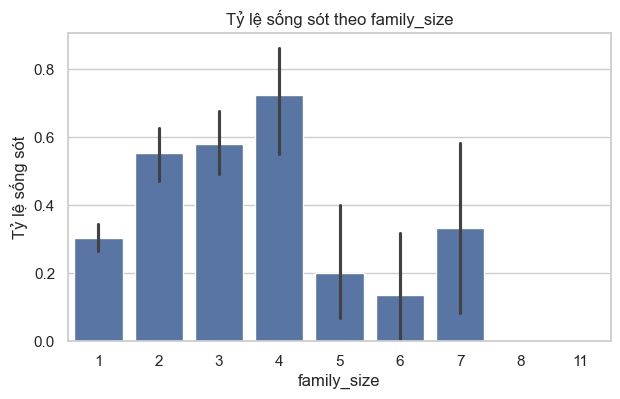

In [14]:
# Bonus 1 — Feature engineering: family_size
df_bonus = df.copy()
df_bonus["family_size"] = df_bonus["sibsp"] + df_bonus["parch"] + 1

print("Tương quan của family_size với survived:")
print(df_bonus[["family_size", "survived"]].corr().loc["family_size", "survived"])

plt.figure(figsize=(7, 4))
sns.barplot(data=df_bonus, x="family_size", y="survived")
plt.title("Tỷ lệ sống sót theo family_size")
plt.ylabel("Tỷ lệ sống sót")
plt.show()

**Nhận xét:** 
- `family_size` có mối quan hệ KHÔNG tuyến tính với survived - đi một mình (`family_size=1`) hoặc gia đình quá đông (`family_size>=5`) đều có tỷ lệ sống sót thấp hơn nhóm gia đình vừa (2-4 người).
- Giả thuyết: người đi một mình thiếu người hỗ trợ lúc sơ tán, còn gia đình quá đông khó di chuyển/tập hợp đủ người cùng lúc.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
